In [14]:
import numpy as np
import matplotlib.pyplot as plt
from plot_timeseries import (
    distributions,
    generate_ground_truth,
    sample_parameters,
)

In [15]:
def owens_bozic_model(y, t, params):
    T, E, C, M = y
    a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma = params

    C = max(C, 0)
    E = max(E, 0)

    tol = 1e-10

    if T < tol:
        DE = 0
    elif E < T:
        DE = dE * (E / T)**l / (s + (E / T)**l) * T
    else:
        DE = dE * (1 - s / (s + (T/E)**(-l))) * T

    if T < tol:
        DC = 0
    elif C < T:
        DC = dC * (C / T)**l / (s + (C / T)**l) * T
    else:
        DC = dC * (1 - s / (s + (T/C)**(-l))) * T

    dT_dt = a * T * (1 - b * T) - DE - DC - KT * (1 - np.exp(-M)) * T
    dE_dt = g - mE * E - jE * np.log((E + C) / K) * (DE**2) / (k + DE**2) * E  - qE * E * T - KE * (1 - np.exp(-M)) * E
    dC_dt = - mC * C - jC * np.log((E + C) / K) * (DC**2) / (k + DC**2) * C - qC * C * T - KC * (1 - np.exp(-M)) * C
    dM_dt = - gamma * M

    return [dT_dt, dE_dt, dC_dt, dM_dt]

## error models

In [16]:
def add_noise_prop(obs: np.ndarray, prop_sd_factor: float, seed=42) -> np.ndarray:
    np.random.seed(seed)
    return np.clip(
        obs * (1 + prop_sd_factor * np.random.normal(size=obs.size)), 0, None
    )

def add_noise_lognormal(obs: np.ndarray, sd: float, seed=42) -> np.ndarray:
    np.random.seed(seed)
    return obs * np.exp(sd * np.random.normal(size=obs.size))

### seeing how the plots look

In [17]:
# Cell #4

import numpy as np
import matplotlib.pyplot as plt

def plot_ground_truth_with_noisy_overlays(
    ax: plt.Axes, # Type hint for ax
    obs_time_ground_truth: list[float], 
    ground_truth: np.ndarray, 
    obs_time_reduced: list[float], 
    noisy_trials: list[np.ndarray], 
    base_color: str,                  # Added base_color parameter
    noisy_labels: list[str] = None, 
    ground_truth_label: str = "Ground Truth",
    # title parameter is now for the subplot title, set by the calling loop
    title: str = "Time Series Data", 
    semilogy: bool = False,
):
    """
    Plot a ground truth timeseries with several noisy overlays on a given Axes,
    with enhanced aesthetics and matching colors.

    Parameters:
        ax: Matplotlib Axes object.
        obs_time_ground_truth: 1D array-like of time points for the ground truth.
        ground_truth: 1D array-like of ground truth values.
        obs_time_reduced: 1D array-like of time points for the noisy trials.
        noisy_trials: List of 1D array-like noisy timeseries.
        base_color: Base color for the current scenario (CR or NR).
        noisy_labels: Optional list of labels for the noisy trials.
        ground_truth_label: Label for the ground truth timeseries.
        title: Title for the subplot.
        semilogy: If True, produce a semilogy plot with y-values clipped at 0.01.
    """
    # Define font sizes for better readability
    font_size_title = 18       # Subplot title
    font_size_labels = 16      # X and Y axis labels
    font_size_ticks = 14       # Tick labels
    font_size_legend = 14      # Legend
    log_floor = 1e-2           # Floor for log scale plotting

    # Prepare data for plotting (clipping for log scale)
    if semilogy:
        ground_truth_plot = np.maximum(ground_truth, log_floor)
        noisy_trials_plot = [np.maximum(trial, log_floor) for trial in noisy_trials]
    else:
        ground_truth_plot = ground_truth
        noisy_trials_plot = noisy_trials

    # Plot Ground Truth curve
    ax.plot(obs_time_ground_truth, ground_truth_plot, 
            label=ground_truth_label, 
            color=base_color,      # Use base_color
            linewidth=3.0,         # Increased linewidth
            alpha=0.8)             # Slight alpha for better visual if lines overlap

    # Plot Noisy Trial observation points
    for i, trial_data in enumerate(noisy_trials_plot):
        label = noisy_labels[i] if noisy_labels and i < len(noisy_labels) else f"Noisy Data {i+1}"
        ax.plot(obs_time_reduced, trial_data, "o", # Use 'o' for circular markers
                label=label, 
                color=base_color,      # Match base_color for dots
                markersize=7,          # Adjusted marker size
                markeredgecolor='black', # Optional: add edge to markers
                markeredgewidth=0.5,
                alpha=0.9)            

    # Set labels, title, and legend with increased font sizes
    ax.set_xlabel("Time (days)", fontsize=font_size_labels)
    ax.set_ylabel("Population / Level", fontsize=font_size_labels) # More generic Y label
    ax.set_title(title, fontsize=font_size_title, fontweight='bold')
    
    ax.tick_params(axis='both', which='major', labelsize=font_size_ticks)
    
    if semilogy:
        ax.set_yscale('log')
        # Optional: Set y-limits for log scale if needed, e.g., if auto-scaling is not ideal
        # current_min_val = np.min(ground_truth_plot[ground_truth_plot > 0]) # Min of positive values
        # ax.set_ylim(bottom=max(log_floor / 10, current_min_val / 10))


    ax.legend(fontsize=font_size_legend, loc='best')
    ax.grid(True, which="both", linestyle='--', linewidth=0.7, alpha=0.6) # More subtle grid


In [18]:
pop_param_info = [
    (3.3e-1, 0.6),
    (2.26e-11, 5.1),
    (3.17, 0.6),
    (2.25, 0.01),
    (1.03e4, 1.7),
    (1.56e-2, 0.75),
    (3.46e-1, 0.75),
    (5.21e8, 1.5),
    (8.67e6, 3.0),
    (1.418, 0.013),
    (1.76e-2, 0.76),
    (0.293, 0.01),
    (1.28e-10, 1.35),
    (2.14e-10, 2.6),
    (3.02e-1, 0.17),
    (0.7, 0.01),
    (0.6, 0.01),
    (0.6, 0.01),
    (0.9, 0.01),
]

init_cond_info = [
    (1.58e9, 1.5),
    (4e5, 0.01),
    (6.3e7, 2.0),
    (6.0, 0.2),
]

pop_param_means, pop_param_stds = zip(*pop_param_info)
init_cond_means, init_cond_stds = zip(*init_cond_info)
n_samples = 5

param_lists = sample_parameters(
    pop_param_means,
    [distributions["lognormal"]] * len(pop_param_info),
    pop_param_stds,
    n_samples=n_samples,
)
init_cond_lists = sample_parameters(
    init_cond_means,
    [distributions["lognormal"]] * len(init_cond_info),
    init_cond_stds,
    n_samples,
)

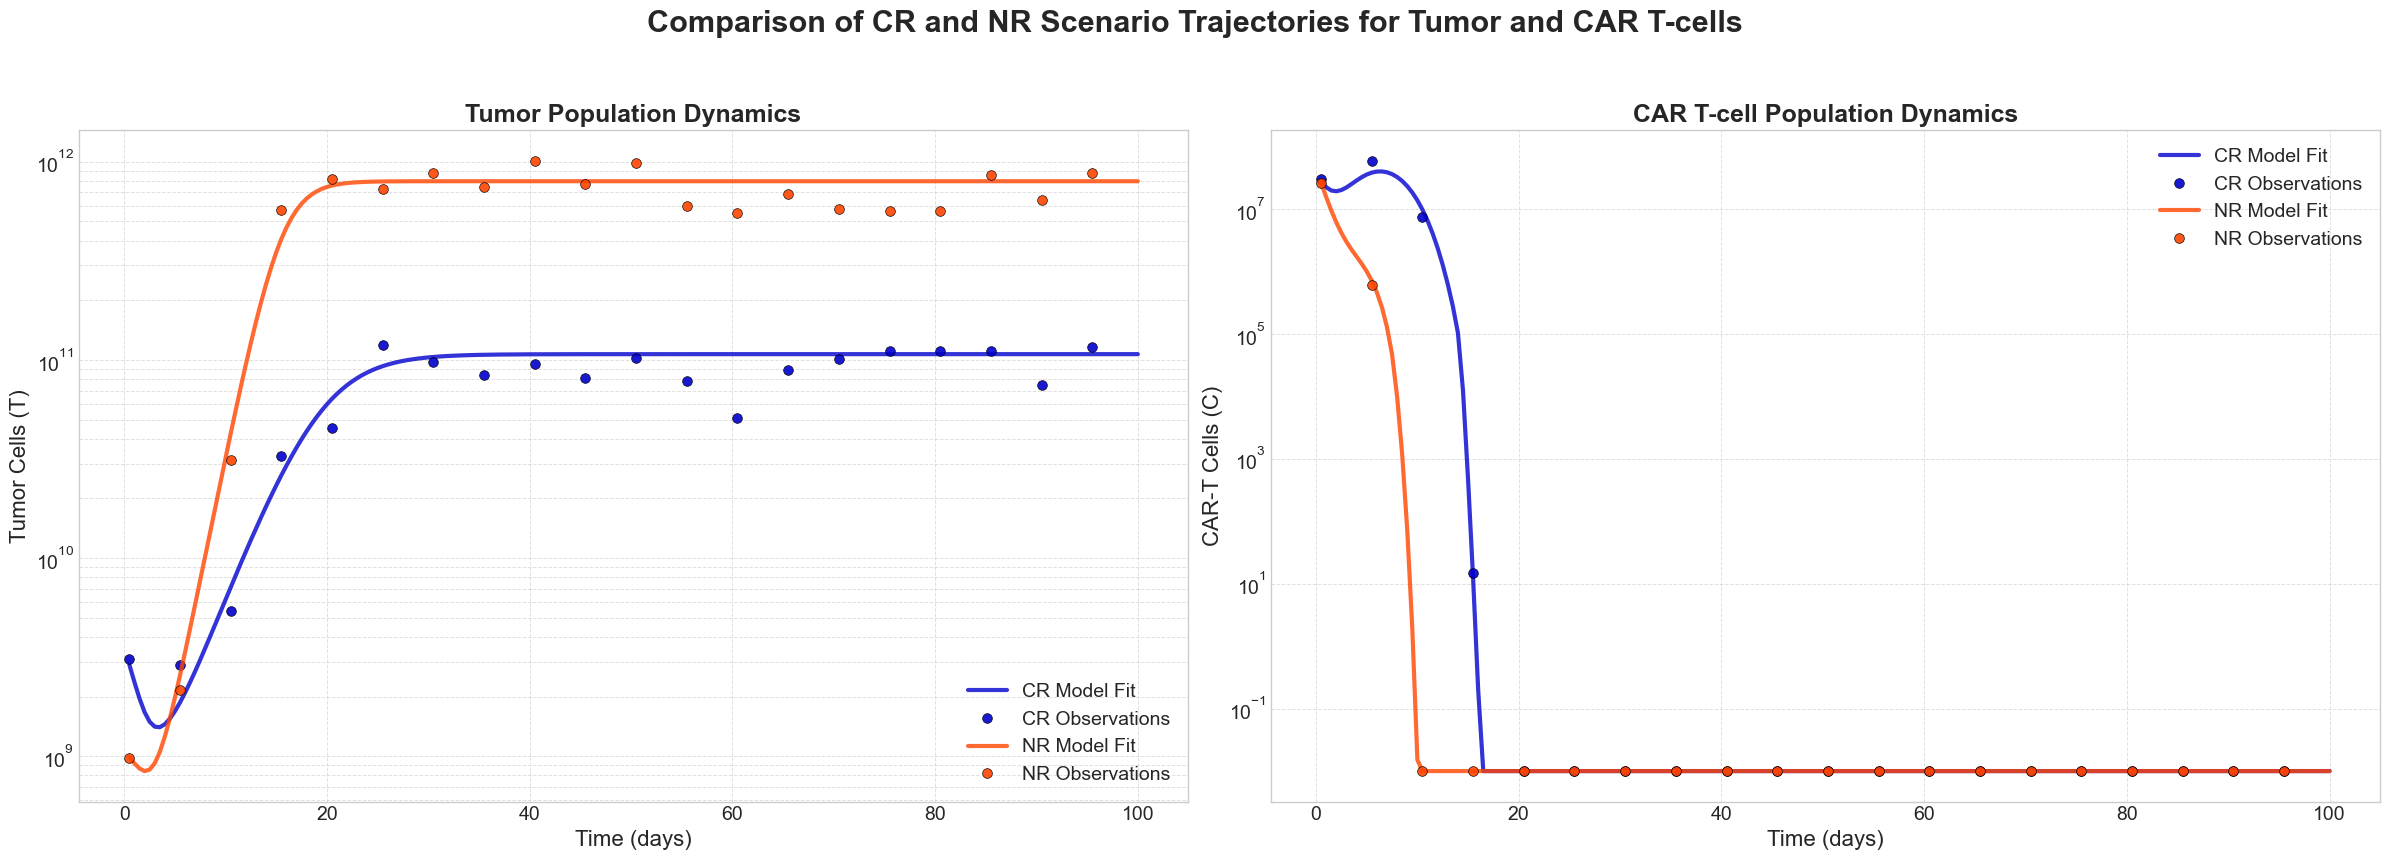

In [19]:
# Cell #6
import numpy as np # Assuming numpy is imported in Cell 1
import matplotlib.pyplot as plt # Assuming matplotlib.pyplot is imported in Cell 1
# Assuming other necessary definitions (pop_param_info, init_cond_info, sample_parameters,
# distributions, generate_ground_truth, owens_bozic_model, add_noise_prop) 
# are available from previous cells.

# --- Data Setup (from your Cell #5, slightly adapted for clarity) ---
pop_param_info = [
    (3.3e-1, 0.6), (2.26e-11, 5.1), (3.17, 0.6), (2.25, 0.01), (1.03e4, 1.7),
    (1.56e-2, 0.75), (3.46e-1, 0.75), (5.21e8, 1.5), (8.67e6, 3.0), (1.418, 0.013),
    (1.76e-2, 0.76), (0.293, 0.01), (1.28e-10, 1.35), (2.14e-10, 2.6), (3.02e-1, 0.17),
    (0.7, 0.01), (0.6, 0.01), (0.6, 0.01), (0.9, 0.01),
]
init_cond_info = [
    (1.58e9, 1.5), (4e5, 0.01), (6.3e7, 2.0), (6.0, 0.2),
]

pop_param_means, pop_param_stds_log = zip(*pop_param_info) # Assuming stds are for log-transformed params
init_cond_means, init_cond_stds_log = zip(*init_cond_info) # Assuming stds are for log-transformed params
n_individuals_to_sample = 5 # Renamed from n_samples to avoid confusion

# Sample parameters for different individuals/scenarios
# Ensure 'distributions' is defined (e.g., from plot_timeseries or synthetic_data)
param_lists_all_indivs = sample_parameters(
    pop_param_means,
    [distributions["lognormal"]] * len(pop_param_info), 
    pop_param_stds_log,
    n_samples=n_individuals_to_sample, # Use the renamed variable
    seed=42 # Added seed for reproducibility
)
init_cond_lists_all_indivs = sample_parameters(
    init_cond_means,
    [distributions["lognormal"]] * len(init_cond_info), 
    init_cond_stds_log,
    n_samples=n_individuals_to_sample, # Use the renamed variable
    seed=123 # Different seed for initial conditions if desired
)

# --- Simulation and Plotting Parameters ---
noise_level_prop_factor = 0.25
num_points_ground_truth = 200
num_points_observations = 20
max_simulation_time = 100
num_noisy_realizations = 1 # Number of noisy observation sets per ground truth

# Define colors for CR and NR scenarios for better visual distinction
scenario_base_colors = {
    'CR': 'mediumblue',   # A strong, clear blue
    'NR': 'orangered'     # A distinct reddish-orange
}
# Define titles for subplots based on gt_idx
subplot_titles_map = {
    0: "Tumor Population Dynamics",      # gt_idx 0 corresponds to T
    2: "CAR T-cell Population Dynamics"  # gt_idx 2 corresponds to C
}
# Define Y-axis labels for subplots
subplot_ylabels_map = {
    0: "Tumor Cells (T)",
    2: "CAR-T Cells (C)"
}

# --- Plotting Loop ---
plt.style.use('seaborn-v0_8-whitegrid') # Apply a style for better aesthetics
# Create a single figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(24, 9)) # Increased figure size for clarity

# Loop for each type of plot (Tumor, CAR T-cell) to go into a separate subplot
for i_subplot_col, gt_idx_to_plot in enumerate([0, 2]): # gt_idx 0 for T, 2 for C
    ax_current_subplot = axes[i_subplot_col] # Select the current subplot (left or right)

    # Loop for CR (idx=0) and NR (idx=4, assuming these indices in param_lists_all_indivs 
    # correspond to distinct CR/NR parameter sets)
    # param_lists_all_indivs[0] for CR, param_lists_all_indivs[4] for NR
    for scenario_param_list_idx in [0, 4]: 
        scenario_label_str = 'CR' if scenario_param_list_idx == 0 else 'NR'
        current_plot_base_color = scenario_base_colors[scenario_label_str]

        # Generate time points for simulation
        observation_times_gt = np.linspace(max_simulation_time / num_points_ground_truth, 
                                           max_simulation_time, 
                                           num_points_ground_truth)
        
        # Select parameters and initial conditions for the current scenario
        # Using distinct individuals for CR and NR for visual comparison
        current_model_params = param_lists_all_indivs[scenario_param_list_idx] 
        # Assuming init_cond_lists_all_indivs[1] was a specific choice,
        # let's make it consistent or use scenario_param_list_idx for ICs too for clarity
        current_initial_conditions = init_cond_lists_all_indivs[scenario_param_list_idx] 

        # Generate ground truth data for all variables
        all_variables_ground_truth = generate_ground_truth(
            owens_bozic_model, 
            current_model_params, 
            current_initial_conditions, 
            observation_times_gt
        )
        # Select the specific variable's ground truth (T or C)
        specific_variable_ground_truth = all_variables_ground_truth[gt_idx_to_plot]

        # Generate noisy observations based on the selected variable's ground truth
        noisy_observations_list = [
            add_noise_prop(specific_variable_ground_truth, 
                           prop_sd_factor=noise_level_prop_factor, 
                           seed=17 * (i_noise + 1) + scenario_param_list_idx) # Vary seed
            for i_noise in range(num_noisy_realizations)
        ]
        
        # Reduce observation points for plotting noisy data
        reduction_factor_obs = num_points_ground_truth // num_points_observations
        observation_times_reduced_plot = observation_times_gt[::reduction_factor_obs]
        
        # Prepare noisy data for plotting (apply reduction)
        noisy_observations_reduced_for_plot = [
            noisy_data[::reduction_factor_obs] for noisy_data in noisy_observations_list
        ]

        # Plot on the current subplot
        plot_ground_truth_with_noisy_overlays(
            ax_current_subplot,
            observation_times_gt,
            specific_variable_ground_truth,
            observation_times_reduced_plot,
            noisy_observations_reduced_for_plot,
            base_color=current_plot_base_color, # Pass the base color
            semilogy=True, # Always use semilogy as cell counts vary widely
            ground_truth_label=f"{scenario_label_str} Model Fit",
            noisy_labels=[f"{scenario_label_str} Observations" for _ in range(num_noisy_realizations)],
            title=subplot_titles_map[gt_idx_to_plot] # Subplot title
        )
    
    # Set specific Y-axis label for the current subplot after all scenarios are plotted
    ax_current_subplot.set_ylabel(subplot_ylabels_map[gt_idx_to_plot], fontsize=16)


# Add an overall title to the entire figure
fig.suptitle("Comparison of CR and NR Scenario Trajectories for Tumor and CAR T-cells", 
             fontsize=22, fontweight='bold')

# Adjust layout to prevent overlap and make space for suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.94]) # rect=[left, bottom, right, top]
plt.show()


## censoring and generating csvs

[How Monolix handles censored data](https://monolixsuite.slp-software.com/monolix/2024R1/handling-censored-data)